# Data Collection for Coding Agent

This notebook collects code samples for training the coding agent model.

**Target Languages:**
- C# (.NET Core 8+)
- TypeScript (Angular)
- SQL

**Data Sources:**
1. Synthetic data generation
2. Public repositories (GitHub)
3. Documentation examples
4. Common patterns and templates

In [1]:
import os
import json
import pandas as pd
from pathlib import Path
from typing import List, Dict
import requests
from tqdm import tqdm

# Set up paths
DATA_DIR = Path('../data/raw')
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Data collection environment ready!")

Data collection environment ready!


## 1. Define Data Schema

Each code sample will have:
- `id`: Unique identifier
- `language`: Programming language (csharp, typescript, sql)
- `framework`: Specific framework (dotnet8, angular, mssql)
- `description`: What the code does
- `code`: The actual code
- `context`: Additional context or comments
- `category`: Type of code (controller, service, component, query, etc.)

In [2]:
class CodeSample:
    def __init__(self, language: str, framework: str, description: str, 
                 code: str, context: str = "", category: str = ""):
        self.language = language
        self.framework = framework
        self.description = description
        self.code = code
        self.context = context
        self.category = category
    
    def to_dict(self):
        return {
            'language': self.language,
            'framework': self.framework,
            'description': self.description,
            'code': self.code,
            'context': self.context,
            'category': self.category
        }

# Storage for collected samples
code_samples: List[CodeSample] = []

## 2. Synthetic Data Generation - .NET Core 8+ Samples

In [3]:
# .NET Core 8+ Controller Examples
dotnet_samples = [
    CodeSample(
        language="csharp",
        framework="dotnet8",
        description="Create a simple API controller with GET endpoint",
        category="controller",
        code="""using Microsoft.AspNetCore.Mvc;

namespace MyApi.Controllers;

[ApiController]
[Route("api/[controller]")]
public class ProductsController : ControllerBase
{
    [HttpGet]
    public IActionResult GetAll()
    {
        return Ok(new { message = "Products retrieved successfully" });
    }
}""",
        context="ASP.NET Core 8 minimal API controller"
    ),
    CodeSample(
        language="csharp",
        framework="dotnet8",
        description="Create a service with dependency injection",
        category="service",
        code="""public interface IProductService
{
    Task<List<Product>> GetAllAsync();
    Task<Product?> GetByIdAsync(int id);
}

public class ProductService : IProductService
{
    private readonly ApplicationDbContext _context;
    
    public ProductService(ApplicationDbContext context)
    {
        _context = context;
    }
    
    public async Task<List<Product>> GetAllAsync()
    {
        return await _context.Products.ToListAsync();
    }
    
    public async Task<Product?> GetByIdAsync(int id)
    {
        return await _context.Products.FindAsync(id);
    }
}""",
        context="Service pattern with Entity Framework Core"
    ),
    CodeSample(
        language="csharp",
        framework="dotnet8",
        description="Create an Entity Framework model with relationships",
        category="model",
        code="""using System.ComponentModel.DataAnnotations;

public class Product
{
    [Key]
    public int Id { get; set; }
    
    [Required]
    [MaxLength(100)]
    public string Name { get; set; } = string.Empty;
    
    public decimal Price { get; set; }
    
    public int CategoryId { get; set; }
    public Category? Category { get; set; }
}

public class Category
{
    [Key]
    public int Id { get; set; }
    
    [Required]
    public string Name { get; set; } = string.Empty;
    
    public ICollection<Product> Products { get; set; } = new List<Product>();
}""",
        context="EF Core entities with navigation properties"
    ),
    CodeSample(
        language="csharp",
        framework="dotnet8",
        description="Configure JWT authentication in Program.cs",
        category="configuration",
        code="""using Microsoft.AspNetCore.Authentication.JwtBearer;
using Microsoft.IdentityModel.Tokens;
using System.Text;

var builder = WebApplication.CreateBuilder(args);

builder.Services.AddAuthentication(JwtBearerDefaults.AuthenticationScheme)
    .AddJwtBearer(options =>
    {
        options.TokenValidationParameters = new TokenValidationParameters
        {
            ValidateIssuer = true,
            ValidateAudience = true,
            ValidateLifetime = true,
            ValidateIssuerSigningKey = true,
            ValidIssuer = builder.Configuration["Jwt:Issuer"],
            ValidAudience = builder.Configuration["Jwt:Audience"],
            IssuerSigningKey = new SymmetricSecurityKey(
                Encoding.UTF8.GetBytes(builder.Configuration["Jwt:Key"]!))
        };
    });

var app = builder.Build();
app.UseAuthentication();
app.UseAuthorization();
app.Run();""",
        context="JWT authentication setup in .NET 8"
    )
]

code_samples.extend(dotnet_samples)
print(f"Added {len(dotnet_samples)} .NET Core samples")

Added 4 .NET Core samples


## 3. Synthetic Data Generation - Angular/TypeScript Samples

In [4]:
# Angular/TypeScript Examples
angular_samples = [
    CodeSample(
        language="typescript",
        framework="angular",
        description="Create an Angular service with HTTP client",
        category="service",
        code="""import { Injectable } from '@angular/core';
import { HttpClient } from '@angular/common/http';
import { Observable } from 'rxjs';

export interface Product {
  id: number;
  name: string;
  price: number;
}

@Injectable({
  providedIn: 'root'
})
export class ProductService {
  private apiUrl = 'api/products';

  constructor(private http: HttpClient) {}

  getAll(): Observable<Product[]> {
    return this.http.get<Product[]>(this.apiUrl);
  }

  getById(id: number): Observable<Product> {
    return this.http.get<Product>(`${this.apiUrl}/${id}`);
  }

  create(product: Product): Observable<Product> {
    return this.http.post<Product>(this.apiUrl, product);
  }
}""",
        context="Angular service with HttpClient for API calls"
    ),
    CodeSample(
        language="typescript",
        framework="angular",
        description="Create a standalone Angular component",
        category="component",
        code="""import { Component, OnInit } from '@angular/core';
import { CommonModule } from '@angular/common';
import { ProductService, Product } from './product.service';

@Component({
  selector: 'app-product-list',
  standalone: true,
  imports: [CommonModule],
  template: `
    <div class="product-list">
      <h2>Products</h2>
      <div *ngFor="let product of products" class="product-item">
        <h3>{{ product.name }}</h3>
        <p>Price: {{ product.price | currency }}</p>
      </div>
    </div>
  `,
  styles: [`
    .product-list { padding: 20px; }
    .product-item { margin: 10px 0; padding: 10px; border: 1px solid #ccc; }
  `]
})
export class ProductListComponent implements OnInit {
  products: Product[] = [];

  constructor(private productService: ProductService) {}

  ngOnInit(): void {
    this.loadProducts();
  }

  loadProducts(): void {
    this.productService.getAll().subscribe({
      next: (data) => this.products = data,
      error: (err) => console.error('Error loading products', err)
    });
  }
}""",
        context="Standalone Angular component with template"
    ),
    CodeSample(
        language="typescript",
        framework="angular",
        description="Create a reactive form with validation",
        category="form",
        code="""import { Component } from '@angular/core';
import { FormBuilder, FormGroup, Validators, ReactiveFormsModule } from '@angular/forms';
import { CommonModule } from '@angular/common';

@Component({
  selector: 'app-product-form',
  standalone: true,
  imports: [CommonModule, ReactiveFormsModule],
  template: `
    <form [formGroup]="productForm" (ngSubmit)="onSubmit()">
      <div>
        <label>Name:</label>
        <input formControlName="name" />
        <div *ngIf="productForm.get('name')?.invalid && productForm.get('name')?.touched">
          <small>Name is required</small>
        </div>
      </div>
      <div>
        <label>Price:</label>
        <input type="number" formControlName="price" />
      </div>
      <button type="submit" [disabled]="productForm.invalid">Submit</button>
    </form>
  `
})
export class ProductFormComponent {
  productForm: FormGroup;

  constructor(private fb: FormBuilder) {
    this.productForm = this.fb.group({
      name: ['', [Validators.required, Validators.minLength(3)]],
      price: [0, [Validators.required, Validators.min(0)]]
    });
  }

  onSubmit(): void {
    if (this.productForm.valid) {
      console.log(this.productForm.value);
    }
  }
}""",
        context="Reactive form with validation in Angular"
    ),
    CodeSample(
        language="typescript",
        framework="angular",
        description="Create an Angular route guard",
        category="guard",
        code="""import { Injectable } from '@angular/core';
import { CanActivate, Router, ActivatedRouteSnapshot, RouterStateSnapshot } from '@angular/router';
import { AuthService } from './auth.service';

@Injectable({
  providedIn: 'root'
})
export class AuthGuard implements CanActivate {
  constructor(
    private authService: AuthService,
    private router: Router
  ) {}

  canActivate(
    route: ActivatedRouteSnapshot,
    state: RouterStateSnapshot
  ): boolean {
    if (this.authService.isAuthenticated()) {
      return true;
    }

    this.router.navigate(['/login'], {
      queryParams: { returnUrl: state.url }
    });
    return false;
  }
}""",
        context="Route guard for authentication in Angular"
    )
]

code_samples.extend(angular_samples)
print(f"Added {len(angular_samples)} Angular/TypeScript samples")

Added 4 Angular/TypeScript samples


## 4. Synthetic Data Generation - SQL Samples

In [5]:
# Angular/TypeScript Examples
angular_samples = [
    CodeSample(
        language="typescript",
        framework="angular",
        description="Create an Angular service with HTTP client",
        category="service",
        code="""import { Injectable } from '@angular/core';
import { HttpClient } from '@angular/common/http';
import { Observable } from 'rxjs';

export interface Product {
  id: number;
  name: string;
  price: number;
}

@Injectable({
  providedIn: 'root'
})
export class ProductService {
  private apiUrl = 'api/products';

  constructor(private http: HttpClient) {}

  getAll(): Observable<Product[]> {
    return this.http.get<Product[]>(this.apiUrl);
  }

  getById(id: number): Observable<Product> {
    return this.http.get<Product>(`${this.apiUrl}/${id}`);
  }

  create(product: Product): Observable<Product> {
    return this.http.post<Product>(this.apiUrl, product);
  }
}""",
        context="Angular service with HttpClient for API calls"
    ),
    CodeSample(
        language="typescript",
        framework="angular",
        description="Create a standalone Angular component",
        category="component",
        code="""import { Component, OnInit } from '@angular/core';
import { CommonModule } from '@angular/common';
import { ProductService, Product } from './product.service';

@Component({
  selector: 'app-product-list',
  standalone: true,
  imports: [CommonModule],
  template: `
    <div class="product-list">
      <h2>Products</h2>
      <div *ngFor="let product of products" class="product-item">
        <h3>{{ product.name }}</h3>
        <p>Price: {{ product.price | currency }}</p>
      </div>
    </div>
  `,
  styles: [`
    .product-list { padding: 20px; }
    .product-item { margin: 10px 0; padding: 10px; border: 1px solid #ccc; }
  `]
})
export class ProductListComponent implements OnInit {
  products: Product[] = [];

  constructor(private productService: ProductService) {}

  ngOnInit(): void {
    this.loadProducts();
  }

  loadProducts(): void {
    this.productService.getAll().subscribe({
      next: (data) => this.products = data,
      error: (err) => console.error('Error loading products', err)
    });
  }
}""",
        context="Standalone Angular component with template"
    ),
    CodeSample(
        language="typescript",
        framework="angular",
        description="Create a reactive form with validation",
        category="form",
        code="""import { Component } from '@angular/core';
import { FormBuilder, FormGroup, Validators, ReactiveFormsModule } from '@angular/forms';
import { CommonModule } from '@angular/common';

@Component({
  selector: 'app-product-form',
  standalone: true,
  imports: [CommonModule, ReactiveFormsModule],
  template: `
    <form [formGroup]="productForm" (ngSubmit)="onSubmit()">
      <div>
        <label>Name:</label>
        <input formControlName="name" />
        <div *ngIf="productForm.get('name')?.invalid && productForm.get('name')?.touched">
          <small>Name is required</small>
        </div>
      </div>
      <div>
        <label>Price:</label>
        <input type="number" formControlName="price" />
      </div>
      <button type="submit" [disabled]="productForm.invalid">Submit</button>
    </form>
  `
})
export class ProductFormComponent {
  productForm: FormGroup;

  constructor(private fb: FormBuilder) {
    this.productForm = this.fb.group({
      name: ['', [Validators.required, Validators.minLength(3)]],
      price: [0, [Validators.required, Validators.min(0)]]
    });
  }

  onSubmit(): void {
    if (this.productForm.valid) {
      console.log(this.productForm.value);
    }
  }
}""",
        context="Reactive form with validation in Angular"
    ),
    CodeSample(
        language="typescript",
        framework="angular",
        description="Create an Angular route guard",
        category="guard",
        code="""import { Injectable } from '@angular/core';
import { CanActivate, Router, ActivatedRouteSnapshot, RouterStateSnapshot } from '@angular/router';
import { AuthService } from './auth.service';

@Injectable({
  providedIn: 'root'
})
export class AuthGuard implements CanActivate {
  constructor(
    private authService: AuthService,
    private router: Router
  ) {}

  canActivate(
    route: ActivatedRouteSnapshot,
    state: RouterStateSnapshot
  ): boolean {
    if (this.authService.isAuthenticated()) {
      return true;
    }

    this.router.navigate(['/login'], {
      queryParams: { returnUrl: state.url }
    });
    return false;
  }
}""",
        context="Route guard for authentication in Angular"
    )
]

code_samples.extend(angular_samples)
print(f"Added {len(angular_samples)} Angular/TypeScript samples")

Added 5 SQL samples


## 5. Save Collected Data

In [6]:
# Convert to DataFrame
df = pd.DataFrame([sample.to_dict() for sample in code_samples])

# Add unique IDs
df['id'] = range(1, len(df) + 1)

# Display statistics
print(f"\nTotal samples collected: {len(df)}")
print("\nSamples by language:")
print(df['language'].value_counts())
print("\nSamples by category:")
print(df['category'].value_counts())

# Save to CSV
csv_path = DATA_DIR / 'code_samples.csv'
df.to_csv(csv_path, index=False)
print(f"\nData saved to: {csv_path}")

# Save to JSON for better code preservation
json_path = DATA_DIR / 'code_samples.json'
df.to_json(json_path, orient='records', indent=2)
print(f"Data saved to: {json_path}")

# Display sample
print("\nSample data:")
df.head()


Total samples collected: 13

Samples by language:
language
sql           5
csharp        4
typescript    4
Name: count, dtype: int64

Samples by category:
category
service          2
query            2
controller       1
model            1
configuration    1
component        1
form             1
guard            1
ddl              1
procedure        1
index            1
Name: count, dtype: int64

Data saved to: ..\data\raw\code_samples.csv
Data saved to: ..\data\raw\code_samples.json

Sample data:


,language,framework,description,code,context,category,id
0,csharp,dotnet8,Create a simple API controller with GET endpoint,using Microsoft.AspNetCore.Mvc;\n\nnamespace M...,ASP.NET Core 8 minimal API controller,controller,1
1,csharp,dotnet8,Create a service with dependency injection,public interface IProductService\n{\n Task<...,Service pattern with Entity Framework Core,service,2
2,csharp,dotnet8,Create an Entity Framework model with relation...,using System.ComponentModel.DataAnnotations;\n...,EF Core entities with navigation properties,model,3
3,csharp,dotnet8,Configure JWT authentication in Program.cs,using Microsoft.AspNetCore.Authentication.JwtB...,JWT authentication setup in .NET 8,configuration,4
4,typescript,angular,Create an Angular service with HTTP client,import { Injectable } from '@angular/core';\ni...,Angular service with HttpClient for API calls,service,5


## 6. Data Quality Check

In [7]:
#!pip install matplotlib


Missing values:
language       0
framework      0
description    0
code           0
context        0
category       0
id             0
dtype: int64

Code length statistics:
count      13.000000
mean      555.461538
std       330.542891
min       102.000000
25%       301.000000
50%       544.000000
75%       669.000000
max      1210.000000
Name: code_length, dtype: float64


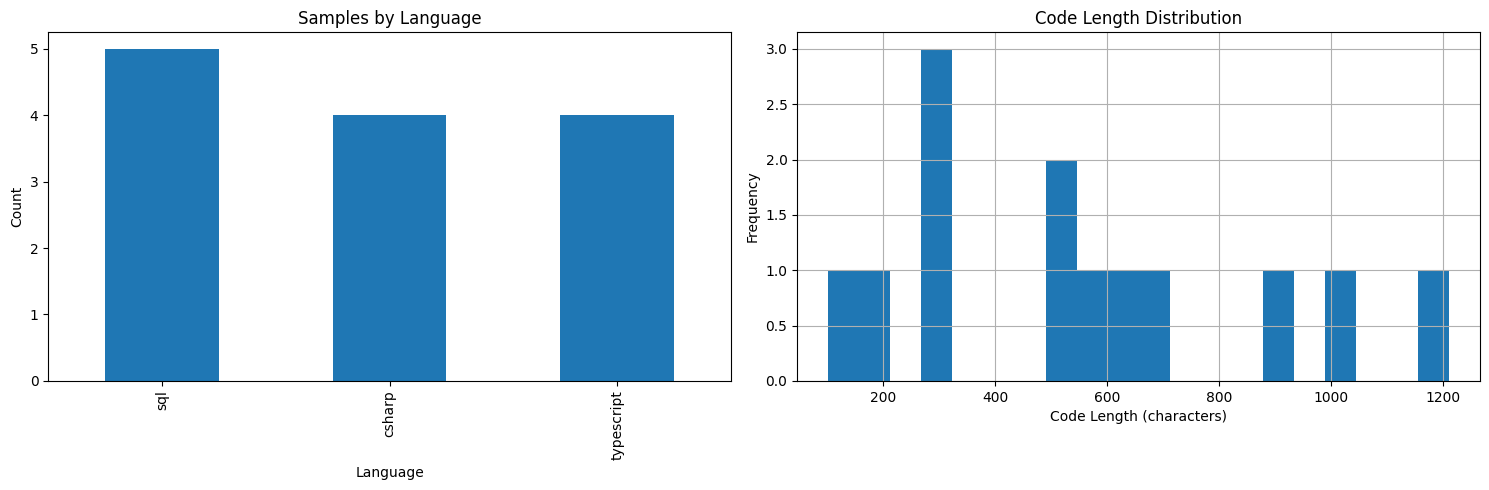


Data collection complete!


In [8]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check code length distribution
df['code_length'] = df['code'].str.len()
print("\nCode length statistics:")
print(df['code_length'].describe())

# Visualize distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Language distribution
df['language'].value_counts().plot(kind='bar', ax=axes[0], title='Samples by Language')
axes[0].set_xlabel('Language')
axes[0].set_ylabel('Count')

# Code length distribution
df['code_length'].hist(bins=20, ax=axes[1])
axes[1].set_title('Code Length Distribution')
axes[1].set_xlabel('Code Length (characters)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\nData collection complete!")

## Next Steps

1. Run notebook `02_data_preprocessing.ipynb` to clean and prepare the data
2. Consider adding more samples from:
   - Your own codebase
   - GitHub repositories
   - Official documentation
3. Expand categories (middleware, authentication, testing, etc.)